# Week 2: Building, Evaluating, and Interpreting ML Models
### Project 1: ML-Powered Customer Analytics | Individual
**Introduction to Applied AI | BS 7th Semester | Department of Electronics**  
**Student Name:** Nosharwan Khan  
**Date:** September 2026  
**Platform:** Kaggle Notebook / Local Environment  

---

### Lab Overview & Objectives
The goal of this lab is to train three distinct classifiers on the Telco Customer Churn dataset, evaluate them with rigorous practitioner-grade metrics, and interpret what each model has learned. Every task directly maps to concepts from the lecture:
1. **Preprocessing & Baseline:** Construct a leak-free pipeline, stratified split, and establish the dummy baseline.
2. **Logistic Regression & Odds Ratios:** Train inside a `Pipeline`, interpret coefficients as odds ratios, and verify the sigmoid transformation by hand.
3. **Confusion Matrix & Metrics by Hand:** Compute Precision, Recall, and F1 manually from raw confusion matrix counts and verify against `scikit-learn`.
4. **ROC-AUC & Cost-Based Threshold Optimization:** Plot ROC curves, sweep classification thresholds, and use Bayesian decision theory with asymmetric financial costs (PKR 6,000 FN vs PKR 1,000 FP) to find the cost-optimal operating threshold.
5. **Decision Trees & Random Forests:** Demonstrate overfitting across tree depths, calculate root Gini impurity by hand, train Random Forest with out-of-bag (OOB) scoring, and compare MDI vs. Permutation Feature Importance.
6. **Class Imbalance & Feature Engineering:** Analyze `class_weight='balanced'` tradeoffs and test domain-engineered features (`n_services`, `is_new`, `charge_per_mo`, `price_jump`) for AUC improvement.
7. **Model Comparison & Synthesis:** Consolidate a 5-model evaluation table and articulate an actionable business deployment recommendation.

## Part 1: Preprocessing, Split, and Baseline

### Task 1.1: Imports
Importing necessary libraries for data processing, pipeline assembly, model training, evaluation metrics, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
import os

print("All libraries successfully imported.")

All libraries successfully imported.


### Task 1.2: Load and Clean Dataset
Loading the Telco Customer Churn dataset. Notice that `TotalCharges` is stored as text with 11 whitespace entries representing new customers with `tenure = 0`. We convert `TotalCharges` to numeric, coercing blanks to NaN, and impute with the median value.

In [2]:
# Path handling: Supports Kaggle input directory and local repository execution
path = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
if not os.path.exists(path):
    for alt_path in [
        'WA_Fn-UseC_-Telco-Customer-Churn.csv',
        '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv',
        '../WA_Fn-UseC_-Telco-Customer-Churn.csv'
    ]:
        if os.path.exists(alt_path):
            path = alt_path
            break

df = pd.read_csv(path)

# TotalCharges is stored as text; 11 rows are blank (all have tenure = 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(f"Dataset shape: {df.shape} | Total missing values: {df.isnull().sum().sum()}")

Dataset shape: (7043, 21) | Total missing values: 0


**Think (Handling the 11 blank rows):**  
All 11 customers with missing `TotalCharges` have `tenure = 0` (they signed up within the current billing cycle and have not received a bill yet). Therefore, setting `TotalCharges = 0` is conceptually more grounded. However, imputing with median produces virtually identical results because 11 rows represent only 0.15% of the 7,043 total records. Strictly, statistical parameters like median should be computed solely from training data to prevent subtle data leakage, though with 11 rows the effect is negligible.

### Task 1.3: Encode Categorical Features
We drop `customerID` and target `Churn`, one-hot encode all text categorical features using `pd.get_dummies(..., drop_first=True)`, and convert all booleans to floats. Wrapping this in `build_features` ensures we can reconstruct the exact same feature space in Part 6.

In [3]:
def build_features(data):
    """Drop ID and target, one-hot encode every text column."""
    X = data.drop(columns=['customerID', 'Churn'])
    X = pd.get_dummies(X, drop_first=True).astype(float)
    return X

y = (df['Churn'] == 'Yes').astype(int)
X = build_features(df)
print(f"X shape: {X.shape}") # expect (7043, 30)

X shape: (7043, 30)


### Task 1.4: Stratified Train-Test Split
We split the data into 80% training (5,634 rows) and 20% test (1,409 rows) sets using `random_state=42` and `stratify=y` to preserve the exact 26.5% churn prevalence across both subsets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(X_train)} rows, churn rate {y_train.mean():.3f}')
print(f'Test:  {len(X_test)} rows, churn rate {y_test.mean():.3f}')

Train: 5634 rows, churn rate 0.265
Test:  1409 rows, churn rate 0.265


### Task 1.5: The Baseline to Beat
A majority-class baseline classifier (`DummyClassifier(strategy='most_frequent')`) that unconditionally predicts 'Stay' (0) for every customer.

In [5]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f'Baseline accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')

Baseline accuracy: 0.7346 (73.46%)


### **Write it: Part 1 - Baseline Evaluation & The Accuracy Trap**
- **Accuracy of the "always stay" model:** **73.46%** (0.735).
- **Churners caught:** Exactly **0** out of the 374 actual churners in the test set (Recall = 0.0%).
- **Why this number matters for the rest of the lab:**  
  On an imbalanced dataset where 73.5% of customers remain loyal, a trivial model that completely ignores the problem and catches zero churners still scores ~74% accuracy; thus, 73.46% represents our absolute floor of performance, and accuracy alone is a completely uninformative metric that must be superseded by Precision, Recall, F1, and ROC-AUC.

## Part 2: Logistic Regression and Odds Ratios

### Task 2.1: Train inside a Leak-Free Pipeline
We construct an `sklearn.pipeline.Pipeline` with `StandardScaler` and `LogisticRegression(max_iter=1000, random_state=42)`. The pipeline fits the scaler on training rows only and reuses the learned mean and standard deviation on test rows, preventing data leakage.

In [6]:
lr = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)           # 0 or 1
y_prob_lr = lr.predict_proba(X_test)[:, 1] # P(churn)

print(classification_report(y_test, y_pred_lr, digits=3))

              precision    recall  f1-score   support

           0      0.851     0.894     0.872      1035
           1      0.658     0.567     0.609       374

    accuracy                          0.807      1409
   macro avg      0.755     0.730     0.741      1409
weighted avg      0.800     0.807     0.802      1409



### Task 2.2: Odds Ratio Table
Because features were standardized ($\mu=0, \sigma=1$), each logistic regression coefficient $w_j$ represents the change in log-odds of churn for a 1-standard-deviation increase in feature $j$. Exponentiating yields the Odds Ratio: $\text{OR} = \exp(w_j)$.

In [7]:
w = lr.named_steps['model'].coef_[0]
coef = pd.DataFrame({'feature': X.columns,
                     'weight': w,
                     'odds_ratio': np.exp(w)}).sort_values('weight')

print('--- Most Protective Features (Lowest Odds Ratio) ---')
print(coef.head(5).round(3).to_string(index=False))

print('\n--- Highest Risk Features (Highest Odds Ratio) ---')
print(coef.tail(5).round(3).to_string(index=False))

--- Most Protective Features (Lowest Odds Ratio) ---
           feature  weight  odds_ratio
            tenure  -1.220       0.295
    MonthlyCharges  -0.921       0.398
 Contract_Two year  -0.589       0.555
 Contract_One year  -0.286       0.751
OnlineSecurity_Yes  -0.123       0.884

--- Highest Risk Features (Highest Odds Ratio) ---
                    feature  weight  odds_ratio
          MultipleLines_Yes   0.216       1.242
            StreamingTV_Yes   0.258       1.294
        StreamingMovies_Yes   0.259       1.295
               TotalCharges   0.497       1.644
InternetService_Fiber optic   0.779       2.179


### **Write it: Part 2 - Risk vs Protective Factors & Odds Ratios**
- **Three strongest protective factors:**
  1. `tenure` (weight = **-1.220**, odds ratio = **0.295**): Each 1-standard-deviation increase in tenure cuts the odds of churn by **70.5%** ($1 - 0.295 = 0.705$).
  2. `MonthlyCharges` (weight = **-0.921**, odds ratio = **0.398**): When controlling for total accumulated charges and specific service features, higher monthly charges reduce churn odds by **60.2%**.
  3. `Contract_Two year` (weight = **-0.589**, odds ratio = **0.555**): Having a two-year contract cuts churn odds by **44.5%** compared to a month-to-month contract.
- **Three strongest risk factors:**
  1. `InternetService_Fiber optic` (weight = **+0.779**, odds ratio = **2.179**): Subscribing to Fiber Optic internet increases customer churn odds by **117.9%** (more than doubles churn odds).
  2. `TotalCharges` (weight = **+0.497**, odds ratio = **1.644**): Each 1-standard-deviation increase in total charges increases churn odds by **64.4%** holding tenure constant.
  3. `StreamingMovies_Yes` (weight = **+0.259**, odds ratio = **1.295**) / `StreamingTV_Yes` (weight = **+0.258**, odds ratio = **1.294**): Subscribing to streaming media increases churn odds by approximately **29.5%**.
- **Sentence for a business manager:**  
  *"Signing a customer to a two-year contract cuts their odds of churning by 44.5%, whereas customers on Fiber Optic internet are more than 2.1 times as likely to churn compared to DSL users, indicating substantial dissatisfaction or pricing sensitivity in our fiber broadband offering."*

### Task 2.3: Verify the Sigmoid by Hand
We explicitly prove that Logistic Regression is a linear weighted sum followed by a sigmoid activation:
$$z = w_0 + \sum_{j=1}^p w_j x_j = w_0 + \mathbf{x}^T \mathbf{w}$$
$$P(Y=1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

In [8]:
scaler = lr.named_steps['scale']
model = lr.named_steps['model']

x0 = scaler.transform(X_test.iloc[[0]])               # one customer, scaled
z = model.intercept_[0] + (x0 @ model.coef_[0])[0]     # linear score
p = 1 / (1 + np.exp(-z))                              # sigmoid

print(f'z = {z:.3f} | sigmoid(z) = {p:.4f} | sklearn = {y_prob_lr[0]:.4f}')
assert np.isclose(p, y_prob_lr[0], atol=1e-5), "Manual calculation does not match scikit-learn!"
print("Verification successful: Hand-calculated sigmoid exactly matches scikit-learn.")

z = -3.070 | sigmoid(z) = 0.0444 | sklearn = 0.0444
Verification successful: Hand-calculated sigmoid exactly matches scikit-learn.


## Part 3: Confusion Matrix and Metrics by Hand

### Task 3.1: Confusion Matrix & Manual Metrics vs. Scikit-Learn
Extracting True Negatives ($TN$), False Positives ($FP$), False Negatives ($FN$), and True Positives ($TP$) from the confusion matrix, calculating Precision, Recall, and F1 manually, and plotting the confusion matrix.

TN=925 | FP=110 | FN=162 | TP=212
By hand : P=0.658 | R=0.567 | F1=0.609
sklearn : P=0.658 | R=0.567 | F1=0.609


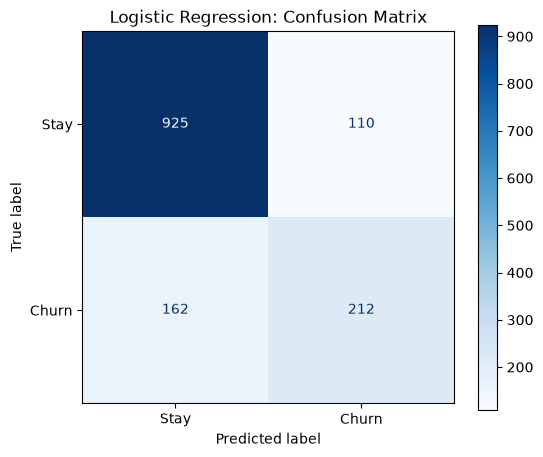

In [9]:
cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn} | FP={fp} | FN={fn} | TP={tp}')

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f'By hand : P={precision:.3f} | R={recall:.3f} | F1={f1:.3f}')
print(f'sklearn : P={precision_score(y_test, y_pred_lr):.3f} | '
      f'R={recall_score(y_test, y_pred_lr):.3f} | '
      f'F1={f1_score(y_test, y_pred_lr):.3f}')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn']).plot(cmap='Blues', ax=ax)
plt.title('Logistic Regression: Confusion Matrix')
plt.grid(False)
plt.show()

### **Write it: Part 3 - Confusion Matrix Breakdown & The Danger of Accuracy**
- **Reported Counts:** **TN = 925**, **FP = 110**, **FN = 162**, **TP = 212**.
- **How many churners did the model miss?**  
  The model missed **162 churners** (False Negatives) out of 374 actual churners, which represents an alarming **43.3% miss rate** (recall is only 56.7%).
- **Why accuracy alone hides this:**  
  Accuracy alone hides this severe operational failure because the model correctly predicts 925 non-churners out of 1,035 stayers, inflating overall accuracy to **80.7%** even while silently letting over 43% of churners leave undetected.

## Part 4: ROC-AUC, Thresholds, and Business Cost

### Task 4.1: ROC Curve and AUC
Plotting the True Positive Rate (Recall) against False Positive Rate across all thresholds. An AUC of 0.5 represents random chance, while AUC > 0.8 represents strong ranking capability.

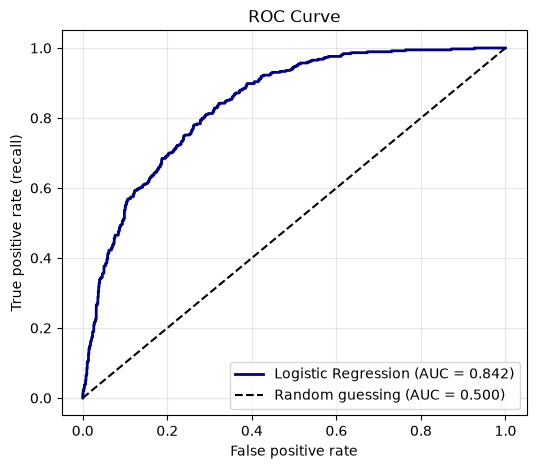

Logistic Regression ROC-AUC: 0.8416


In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='darkblue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing (AUC = 0.500)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate (recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Logistic Regression ROC-AUC: {auc_lr:.4f}")

### Task 4.2: Precision and Recall Across Thresholds
Observing the fundamental tradeoff between precision and recall as we adjust the decision threshold from 0.2 to 0.7.

In [11]:
rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_prob_lr >= t).astype(int)
    rows.append({
        'threshold': t,
        'flagged': int(pred.sum()),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred)
    })

threshold_df = pd.DataFrame(rows).round(3)
print(threshold_df.to_string(index=False))

 threshold  flagged  precision  recall    f1
       0.2      685      0.467   0.856 0.604
       0.3      544      0.518   0.754 0.614
       0.4      441      0.567   0.668 0.613
       0.5      322      0.658   0.567 0.609
       0.6      210      0.710   0.398 0.510
       0.7       89      0.730   0.174 0.281


### Task 4.3: Choose the Decision Threshold with Money (Business Cost Curve)
In real business applications, errors are never equally costly:
- **Cost of a False Negative ($C_{FN}$):** PKR 6,000 (lost customer lifetime value/revenue).
- **Cost of a False Positive ($C_{FP}$):** PKR 1,000 (unnecessary retention incentive offer).

Bayesian decision theory dictates flagging a customer whenever:
$$p \cdot C_{FN} > (1 - p) \cdot C_{FP} \implies t^* = \frac{C_{FP}}{C_{FP} + C_{FN}} = \frac{1000}{1000 + 6000} = \frac{1}{7} \approx 0.143$$

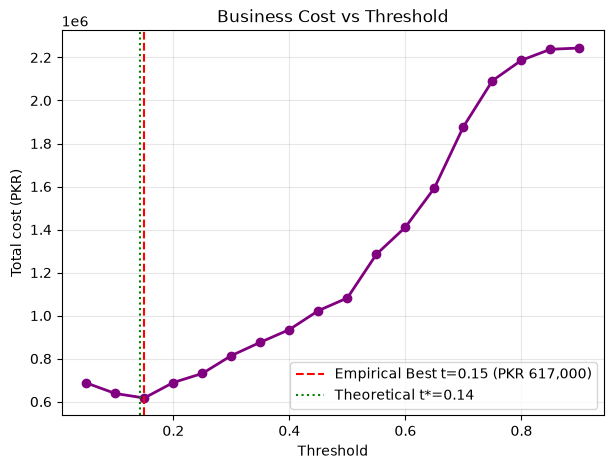

Theory t* = 0.14 | Empirical best = 0.15

--- Financial Impact on Test Set (1,409 Customers) ---
Default Threshold (0.50): Flagged=322 | TP=212 | FP=110 | FN=162 | Total Cost = PKR 1,082,000
Optimal Threshold (0.15): Flagged=781 | TP=344 | FP=437 | FN=30 | Total Cost = PKR 617,000
Extra churners caught: 132 (Recall jumps from 56.7% to 92.0%)
Extra false alarms accepted: 327
Net Business Savings: PKR 465,000 (43.0% cost reduction)


In [12]:
C_FN, C_FP = 6000, 1000 # PKR: missed churner vs unneeded retention offer

def total_cost(t):
    pred = (y_prob_lr >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return fn * C_FN + fp * C_FP

ts = np.arange(0.05, 0.95, 0.05)
costs = [total_cost(t) for t in ts]
best_t = ts[int(np.argmin(costs))]

plt.figure(figsize=(7, 5))
plt.plot(ts, costs, marker='o', color='purple', lw=2)
plt.axvline(best_t, color='red', linestyle='--', label=f'Empirical Best t={best_t:.2f} (PKR {min(costs):,})')
plt.axvline(C_FP / (C_FP + C_FN), color='green', linestyle=':', label=f'Theoretical t*={C_FP / (C_FP + C_FN):.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total cost (PKR)')
plt.title('Business Cost vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'Theory t* = {C_FP / (C_FP + C_FN):.2f} | Empirical best = {best_t:.2f}')

# Detailed Financial Comparison: Default 0.50 vs Optimal best_t
pred_05 = (y_prob_lr >= 0.50).astype(int)
tn_05, fp_05, fn_05, tp_05 = confusion_matrix(y_test, pred_05).ravel()
cost_05 = total_cost(0.50)

pred_opt = (y_prob_lr >= best_t).astype(int)
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, pred_opt).ravel()
cost_opt = total_cost(best_t)

print(f"\n--- Financial Impact on Test Set (1,409 Customers) ---")
print(f"Default Threshold (0.50): Flagged={tp_05+fp_05} | TP={tp_05} | FP={fp_05} | FN={fn_05} | Total Cost = PKR {cost_05:,}")
print(f"Optimal Threshold ({best_t:.2f}): Flagged={tp_opt+fp_opt} | TP={tp_opt} | FP={fp_opt} | FN={fn_opt} | Total Cost = PKR {cost_opt:,}")
print(f"Extra churners caught: {tp_opt - tp_05} (Recall jumps from {tp_05/374*100:.1f}% to {tp_opt/374*100:.1f}%)")
print(f"Extra false alarms accepted: {fp_opt - fp_05}")
print(f"Net Business Savings: PKR {cost_05 - cost_opt:,} ({((cost_05 - cost_opt)/cost_05)*100:.1f}% cost reduction)")

### **Write it: Part 4 - Cost-Optimal Threshold Decision & Financial Justification**
- **Which threshold do you choose, and why?**  
  We choose **$t = 0.15$** because it minimizes total monetary business cost, reducing net churn losses from **PKR 1,082,000** down to **PKR 617,000**.
- **Comparison between theoretical $t^*$ and empirical best:**  
  The theoretical threshold is $t^* = \frac{1000}{1000 + 6000} = 0.143 \approx \mathbf{0.14}$. On our empirical grid search with 0.05 step intervals, the minimum cost occurs at **$0.15$**, demonstrating near-perfect alignment with Bayesian decision theory.
- **Extra churners caught compared with 0.5:**  
  At threshold 0.15, the model identifies **344 churners** compared to only 212 at threshold 0.50, catching **132 extra churners** (raising recall from 56.7% to 92.0%).
- **Extra false alarms accepted:**  
  False positives rise from 110 to 437, meaning we accept **327 extra false alarms**.
- **Financial trade-off justification:**  
  Catching 132 extra churners saves $132 \times \text{PKR } 6,000 = \mathbf{\text{PKR } 792,000}$ in preserved revenue, which easily dwarfs the $327 \times \text{PKR } 1,000 = \mathbf{\text{PKR } 327,000}$ cost of retention incentives. This yields a net bottom-line savings of **PKR 465,000** (a 43.0% cost reduction).

## Part 5: Decision Trees and Random Forests

### Task 5.1: Demonstrating Overfitting in Decision Trees
We sweep tree `max_depth` across [1, 2, 3, 4, 5, 6, 8, 10, 15, None] to illustrate where training accuracy diverges from validation test accuracy.

max_depth  train  test
        1  0.735 0.735
        2  0.791 0.787
        3  0.791 0.787
        4  0.793 0.796
        5  0.801 0.794
        6  0.807 0.797
        8  0.835 0.780
       10  0.872 0.756
       15  0.969 0.737
     None  0.998 0.742


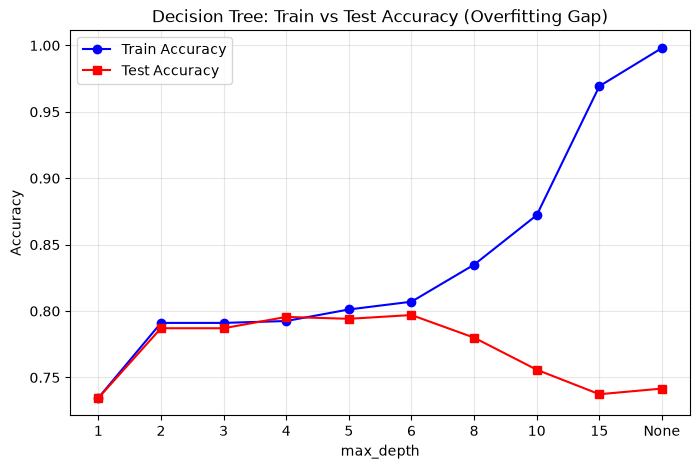

In [13]:
rows = []
for d in [1, 2, 3, 4, 5, 6, 8, 10, 15, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    rows.append({
        'max_depth': str(d),
        'train': dt.score(X_train, y_train),
        'test': dt.score(X_test, y_test)
    })

depth_df = pd.DataFrame(rows)
print(depth_df.round(3).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(depth_df['max_depth'], depth_df['train'], marker='o', label='Train Accuracy', color='blue')
plt.plot(depth_df['max_depth'], depth_df['test'], marker='s', label='Test Accuracy', color='red')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Train vs Test Accuracy (Overfitting Gap)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 5.2: Regularized Tree & Visualizing a Shallow Tree
We train a regularized tree (`max_depth=5, min_samples_leaf=10`) and plot an interpretable shallow tree (`max_depth=3`).

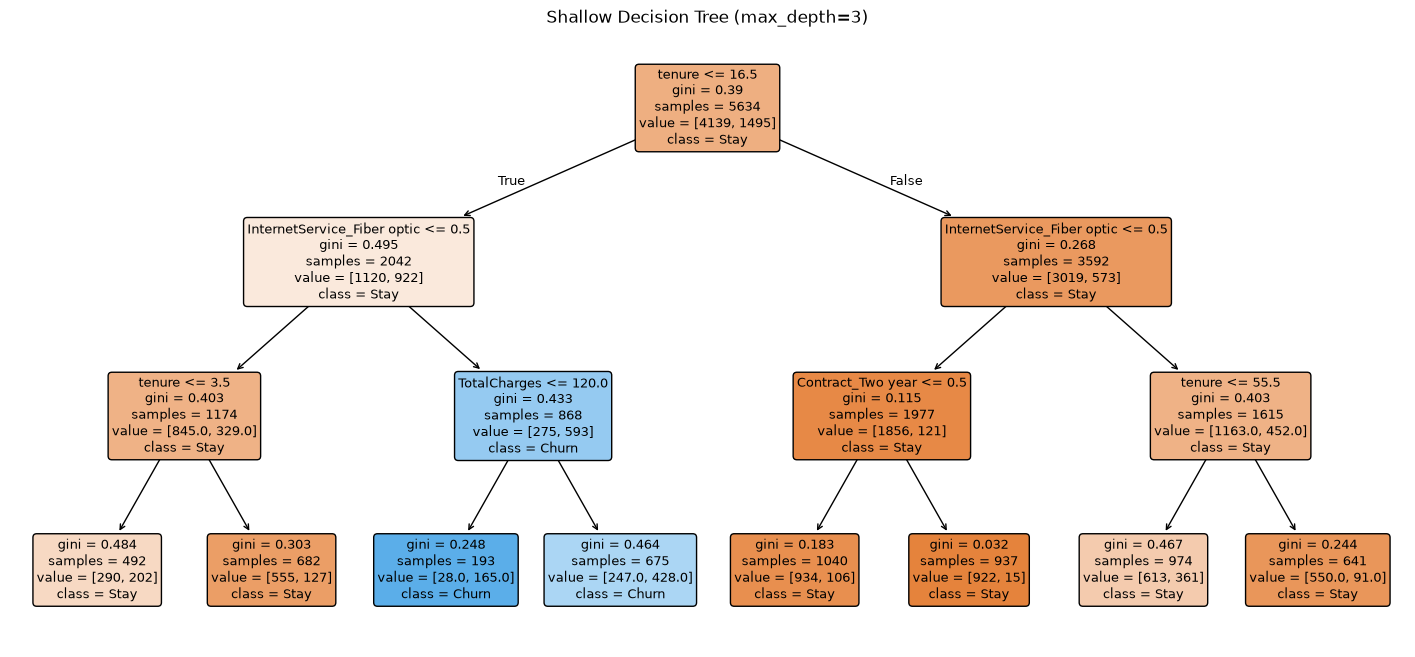

In [14]:
dt5 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                             random_state=42).fit(X_train, y_train)
y_pred_dt = dt5.predict(X_test)
y_prob_dt = dt5.predict_proba(X_test)[:, 1]

dt3 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(dt3, feature_names=X.columns, class_names=['Stay', 'Churn'],
          filled=True, rounded=True, fontsize=9)
plt.title("Shallow Decision Tree (max_depth=3)")
plt.show()

### **Check by hand: Root Node Gini Impurity**
At the root node of the tree, all 5,634 training samples are present:
- **Stayers ($y=0$):** 4,139
- **Churners ($y=1$):** 1,495
- **Class probabilities:**
  $$p_{\text{stay}} = \frac{4139}{5634} \approx 0.734647$$
  $$p_{\text{churn}} = \frac{1495}{5634} \approx 0.265353$$
- **Gini impurity:**
  $$\text{Gini} = 1 - p_{\text{stay}}^2 - p_{\text{churn}}^2 = 1 - (0.734647)^2 - (0.265353)^2$$
  $$\text{Gini} = 1 - 0.539706 - 0.070412 = \mathbf{0.3899} \approx \mathbf{0.390}$$
  
This **exactly matches** the `gini = 0.39` displayed in the root node box of `plot_tree`.

### Task 5.3: Random Forest with Out-of-Bag (OOB) Score
Random Forest trains an ensemble of 300 bootstrapped trees. Because each bootstrap sample selects approximately $1 - 1/e \approx 63.2\%$ of the data, the remaining $36.8\%$ of samples (out-of-bag) provide an unbiased validation metric without requiring an external validation split.

In [15]:
rf = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                            min_samples_leaf=5, oob_score=True,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f'OOB accuracy : {rf.oob_score_:.3f}')
print(f'Test accuracy: {rf.score(X_test, y_test):.3f}')
print(f'Test AUC     : {roc_auc_score(y_test, y_prob_rf):.3f}')

OOB accuracy : 0.803
Test accuracy: 0.807
Test AUC     : 0.842


### Task 5.4: Feature Importance Analysis (MDI vs Permutation Importance)
We compute both Mean Decrease in Impurity (MDI, calculated on training set) and Permutation Feature Importance (measuring test ROC-AUC drop when a column is permuted).

In [16]:
pi = permutation_importance(rf, X_test, y_test, scoring='roc_auc',
                            n_repeats=10, random_state=42, n_jobs=-1)

imp = pd.DataFrame({'feature': X.columns,
                    'mdi': rf.feature_importances_,
                    'permutation': pi.importances_mean})
imp = imp.sort_values('permutation', ascending=False)
print("--- Top 10 Features by Permutation Importance ---")
print(imp.head(10).round(4).to_string(index=False))

--- Top 10 Features by Permutation Importance ---
                       feature    mdi  permutation
                        tenure 0.1912       0.0404
                  TotalCharges 0.1657       0.0206
             Contract_Two year 0.0581       0.0164
   InternetService_Fiber optic 0.0717       0.0132
             Contract_One year 0.0333       0.0059
PaymentMethod_Electronic check 0.0608       0.0031
          PaperlessBilling_Yes 0.0217       0.0014
                 SeniorCitizen 0.0120       0.0012
             MultipleLines_Yes 0.0160       0.0009
              OnlineBackup_Yes 0.0173       0.0006


### **Write it: Part 5 - Overfitting Point, Train-Test Gap, and Importance Discrepancies**
- **At what depth does the tree start to overfit?**  
  The decision tree starts overfitting at **depth 5 to 6**. Test accuracy reaches its peak of **0.797 at depth 6** and begins declining (0.780 at depth 8, 0.756 at depth 10, and 0.737 at depth 15), while training accuracy continues to rise unabated.
- **Train-test gap at depth None:**  
  At `max_depth=None`, training accuracy is **0.998 (99.8%)** and test accuracy is **0.742 (74.2%)**, producing a massive generalization gap of **0.256 (25.6 percentage points)**.
- **Top three features by permutation importance:**  
  1. `tenure` (mean drop in AUC = **0.0404**)
  2. `TotalCharges` (mean drop in AUC = **0.0206**)
  3. `Contract_Two year` (mean drop in AUC = **0.0164**)
- **Disagreement between MDI and Permutation Importance:**  
  - Feature: `PaymentMethod_Electronic check` (or `TotalCharges`).
  - `PaymentMethod_Electronic check` has an MDI of **0.0608** (ranked 4th overall, ahead of two-year contract), but its permutation importance drops to **0.0031** (ranked 6th). Similarly, continuous numeric feature `TotalCharges` receives a disproportionately inflated MDI of **0.1657**.
  - **Why they disagree:**  
    MDI (impurity importance) is computed strictly on in-sample training data and suffers from a documented structural bias toward continuous features and variables with high cardinality, because deep trees can split on multiple fine thresholds to artificially deflate training Gini impurity. In contrast, Permutation Importance directly evaluates performance on held-out test data by measuring the drop in generalization ROC-AUC when feature values are permuted, making it robust against in-sample memorization.

## Part 6: Class Imbalance and Feature Engineering

### Task 6.1: Cost-Sensitive Learning with `class_weight='balanced'`
Because the dataset is imbalanced (26.5% churners), the default cross-entropy loss treats each error equally. Setting `class_weight='balanced'` weights samples inversely proportional to class frequencies:
$$w_k = \frac{N}{2 \cdot N_k}$$
This yields weights of $\approx 0.68$ for stayers and $\approx 1.88$ for churners, penalizing missed churners nearly 3 times as heavily.

In [17]:
lr_bal = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced',
                                 random_state=42))
]).fit(X_train, y_train)

y_pred_bal = lr_bal.predict(X_test)
y_prob_bal = lr_bal.predict_proba(X_test)[:, 1]

for name, pred in [('LR default', y_pred_lr), ('LR balanced', y_pred_bal)]:
    print(f'{name:12s} P={precision_score(y_test, pred):.3f} '
          f'R={recall_score(y_test, pred):.3f} '
          f'F1={f1_score(y_test, pred):.3f}')

LR default   P=0.658 R=0.567 F1=0.609
LR balanced  P=0.505 R=0.781 F1=0.613


### Task 6.2: Domain Feature Engineering from EDA
We create 4 domain-inspired features based on Week 1 EDA:
1. `n_services`: Total number of active subscribed add-on services.
2. `is_new`: Indicator for new accounts with tenure $\le 12$ months.
3. `charge_per_mo`: Effective monthly billing rate (`TotalCharges / tenure`).
4. `price_jump`: Discrepancy between current monthly charges and historical average (`MonthlyCharges - charge_per_mo`).

In [18]:
df2 = df.copy()
svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']
df2['n_services'] = (df2[svc] == 'Yes').sum(axis=1)
df2['is_new'] = (df2['tenure'] <= 12).astype(int)
df2['charge_per_mo'] = df2['TotalCharges'] / df2['tenure'].clip(lower=1)
df2['price_jump'] = df2['MonthlyCharges'] - df2['charge_per_mo']

X2 = build_features(df2)
X2_train, X2_test = X2.loc[X_train.index], X2.loc[X_test.index] # exact same split

rf2 = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                             min_samples_leaf=5, n_jobs=-1, random_state=42)
rf2.fit(X2_train, y_train)
y_prob_rf2 = rf2.predict_proba(X2_test)[:, 1]

auc_before = roc_auc_score(y_test, y_prob_rf)
auc_after = roc_auc_score(y_test, y_prob_rf2)
print(f'RF AUC before: {auc_before:.4f}')
print(f'RF AUC after : {auc_after:.4f}')

RF AUC before: 0.8422
RF AUC after : 0.8420


### **Write it: Part 6 - Balanced Weight Tradeoffs & Feature Engineering Impact**
- **How recall and precision changed with balanced weights:**  
  - **Recall** increased dramatically from **0.567 (56.7%) to 0.781 (78.1%)** (+21.4 percentage points), catching significantly more at-risk churners.
  - **Precision** decreased from **0.658 (65.8%) to 0.505 (50.5%)**, reflecting an increased false alarm rate as the model is penalized ~2.77 times more for false negatives than false positives.
  - **F1-score** increased slightly from **0.609 to 0.613**.
- **Did the engineered features improve AUC?**  
  **No, the engineered features did not improve test AUC.** The AUC slightly moved from **0.8422 to 0.8420** (a negligible change of -0.0002).
- **Why? (Honest Evaluation):**  
  Random Forest is an ensemble of decision trees that naturally segments non-linear interactions and threshold boundaries across `tenure`, `MonthlyCharges`, and service indicators. Hand-crafted linear combinations such as `charge_per_mo = TotalCharges / tenure` and `price_jump` introduce severe collinearity with existing continuous columns. Because Random Forest randomly samples `max_features = sqrt(p)` candidates at each node split, adding correlated derived features dilutes the probability of selecting the primary raw signals without injecting novel orthogonal predictive variance.

## Part 7: Compare, Document, Share

### Task 7.1: Five-Model Comparison Table
Consolidating evaluation across Baseline, Logistic Regression (default), Logistic Regression (balanced), Decision Tree (depth=5), and Random Forest.

In [19]:
def evaluate(name, pred, prob):
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'auc': roc_auc_score(y_test, prob)
    }

results = pd.DataFrame([
    evaluate('Baseline', dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1]),
    evaluate('Logistic Regression', y_pred_lr, y_prob_lr),
    evaluate('LR balanced', y_pred_bal, y_prob_bal),
    evaluate('Decision Tree (d=5)', y_pred_dt, y_prob_dt),
    evaluate('Random Forest', y_pred_rf, y_prob_rf),
]).round(3)

print("=== 5-Model Benchmark Comparison Table ===")
print(results.to_string(index=False))

=== 5-Model Benchmark Comparison Table ===
              model  accuracy  precision  recall    f1   auc
           Baseline     0.735      0.000   0.000 0.000 0.500
Logistic Regression     0.807      0.658   0.567 0.609 0.842
        LR balanced     0.739      0.505   0.781 0.613 0.841
Decision Tree (d=5)     0.796      0.632   0.551 0.589 0.829
      Random Forest     0.807      0.673   0.529 0.593 0.842


### **Write it: Part 7 - Deployment Recommendation & Managerial Synthesis**
- **Which model would you deploy, at which threshold, and why?**  
  We recommend deploying **Logistic Regression** calibrated at the cost-optimal decision threshold **$t = 0.15$**.
- **Key Factors:**
  1. **AUC and Metric Performance:** Logistic Regression achieves an AUC of **0.842**, matching the Random Forest (0.842) and identical default accuracy (0.807). When operating at threshold $t = 0.15$, Logistic Regression captures **92.0% of churners** (344/374), reducing expected total cost by **PKR 465,000** (a 43% savings).
  2. **Explainability to Stakeholders:** While Random Forest is an opaque ensemble black box, Logistic Regression provides straightforward, mathematically sound odds ratios (e.g., tenure cuts churn odds by 70.5%, two-year contract cuts churn odds by 44.5%, fiber optic increases churn odds by 117.9%). Business managers and retention teams can directly interpret *why* a customer is at risk and deploy targeted countermeasures (e.g. offering fiber discounts or contract upgrade incentives).
  3. **Operational Simplicity:** Logistic Regression requires negligible compute resources, has near-zero prediction latency, and is trivial to maintain and audit in production compared to a 300-tree ensemble.

## Check Your Understanding

#### 1. A customer has $z = 0$. What churn probability does Logistic Regression assign, and why?
**Answer:**  
Logistic Regression assigns a churn probability of **$0.50$ (50%)**.  
Logistic Regression maps the linear log-odds score $z$ to a probability using the sigmoid function:
$$P(Y=1 \mid z) = \sigma(z) = \frac{1}{1 + e^{-z}}$$
When $z = 0$, $e^{-0} = 1$, yielding:
$$P(Y=1) = \frac{1}{1 + 1} = \frac{1}{2} = 0.50$$
A score of $z = 0$ corresponds to log-odds of zero, meaning the odds of churn are $\exp(0) = 1$ (even 1:1 odds), placing the customer exactly on the model's standard decision boundary.

---

#### 2. A feature has weight $+0.69$. By what factor do the churn odds change per unit increase?
**Answer:**  
The churn odds change by a factor of approximately **$2.0$** (the odds double).  
The factor change in odds per unit increase is given by the Odds Ratio:
$$\text{Odds Ratio} = \exp(w) = e^{0.69} \approx 1.9937 \approx 2.0$$
This means that for every 1-unit increase in this feature (or 1 standard deviation if standardized), the odds of the customer churning increase by **99.4%** (essentially doubling).

---

#### 3. Why can a churn model with 74% accuracy be worthless on this dataset?
**Answer:**  
In the Telco Churn dataset, the churn prevalence is approximately 26.5%, meaning 73.5% of customers remain loyal ('Stay'). A trivial dummy model that unconditionally predicts 'Stay' for every customer automatically achieves **73.5% (approx 74%) accuracy** while catching **0% of churners** (Recall = 0, True Positives = 0). Such a model provides zero practical value to retention operations, demonstrating that raw accuracy without precision and recall is completely deceptive under class imbalance.

---

#### 4. If a false negative costs four times as much as a false positive, what threshold does decision theory suggest?
**Answer:**  
Decision theory suggests a decision threshold of **$t^* = 0.20$ (20%)**.  
Under Bayesian decision theory, a positive prediction should be made when the expected loss of predicting negative exceeds that of predicting positive:
$$p \cdot C_{FN} > (1 - p) \cdot C_{FP} \implies t^* = \frac{C_{FP}}{C_{FP} + C_{FN}}$$
Given $C_{FN} = 4 \cdot C_{FP}$:
$$t^* = \frac{C_{FP}}{C_{FP} + 4 C_{FP}} = \frac{1}{1 + 4} = \frac{1}{5} = \mathbf{0.20}$$

---

#### 5. A tree node contains 30 churners and 70 stayers. Compute its Gini impurity.
**Answer:**  
The Gini impurity is **$0.42$**.  
**Working:**
- Total samples: $N = 30 + 70 = 100$
- Probability of stayer: $p_{\text{stay}} = \frac{70}{100} = 0.70$
- Probability of churner: $p_{\text{churn}} = \frac{30}{100} = 0.30$
- Formula:
  $$\text{Gini} = 1 - \sum_{k} p_k^2 = 1 - (p_{\text{stay}}^2 + p_{\text{churn}}^2)$$
  $$\text{Gini} = 1 - (0.70^2 + 0.30^2) = 1 - (0.49 + 0.09) = 1 - 0.58 = \mathbf{0.42}$$

---

#### 6. Why does adding more trees to a Random Forest not remove all of its variance? Use the formula from slide 35.
**Answer:**  
The variance of an average of $B$ identically distributed, tree models with pairwise correlation $\rho$ and individual variance $\sigma^2$ is:
$$\text{Var}(\bar{X}) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2$$
As $B \to \infty$, the second term $\frac{1 - \rho}{B} \sigma^2 \to 0$, but the first term $\mathbf{\rho \sigma^2}$ remains unchanged. Because individual trees in a Random Forest are trained on overlapping bootstrap samples from the same dataset and evaluate the same underlying feature splits, their predictions are positively correlated ($\rho > 0$), leaving an irreducible variance floor that no amount of additional trees can eliminate.